<a href="https://colab.research.google.com/github/ferlitakristianihulu25-source/241712025_ferlitakrisianihulu_A2/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ferlita
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:09<00:00, 78.5MB/s]


In [5]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [6]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['dog' 'wild' 'cat']


,image_path,labels
0,/content/animal-faces/afhq/train/dog/flickr_do...,dog
1,/content/animal-faces/afhq/train/dog/flickr_do...,dog
2,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
3,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
4,/content/animal-faces/afhq/train/dog/flickr_do...,dog


In [7]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape, test.shape, val.shape)

(11291, 2) (2419, 2) (2420, 2)


In [8]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [9]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [10]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)

In [11]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/train/dog/pixabay_dog_000727.jpg


In [12]:
train_dataset.__getitem__(2)

(tensor([[[0.1725, 0.1725, 0.1725,  ..., 0.2353, 0.2353, 0.2431],
          [0.1843, 0.1843, 0.1843,  ..., 0.2431, 0.2392, 0.2431],
          [0.1843, 0.1843, 0.1882,  ..., 0.2431, 0.2431, 0.2431],
          ...,
          [0.1922, 0.2078, 0.3255,  ..., 0.2745, 0.2745, 0.2745],
          [0.2039, 0.2353, 0.4235,  ..., 0.2745, 0.2706, 0.2706],
          [0.2157, 0.2784, 0.4745,  ..., 0.2745, 0.2784, 0.2784]],
 
         [[0.2549, 0.2549, 0.2549,  ..., 0.2510, 0.2510, 0.2627],
          [0.2667, 0.2667, 0.2667,  ..., 0.2627, 0.2549, 0.2627],
          [0.2667, 0.2667, 0.2706,  ..., 0.2627, 0.2627, 0.2627],
          ...,
          [0.2549, 0.2549, 0.3137,  ..., 0.2745, 0.2745, 0.2745],
          [0.2706, 0.2706, 0.3804,  ..., 0.2745, 0.2706, 0.2706],
          [0.2824, 0.3020, 0.4157,  ..., 0.2745, 0.2784, 0.2784]],
 
         [[0.2118, 0.2118, 0.2118,  ..., 0.2471, 0.2471, 0.2549],
          [0.2196, 0.2196, 0.2196,  ..., 0.2549, 0.2510, 0.2549],
          [0.2196, 0.2196, 0.2235,  ...,

In [13]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

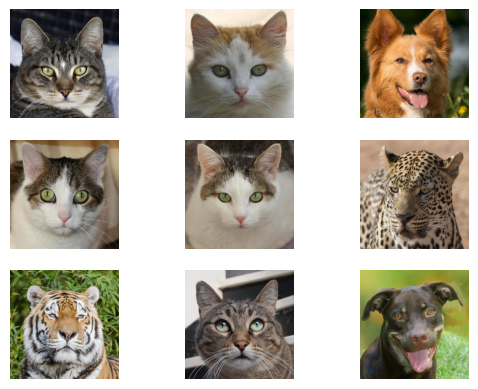

In [14]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [15]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [16]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [17]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding= 1)
    self.batchnorm1 = nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding= 1)
    self.batchnorm2 = nn.BatchNorm2d(64)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding= 1)
    self.batchnorm3 = nn.BatchNorm2d(128)

    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.5) # Added dropout with 0.5 rate

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16), 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.batchnorm1(x) # Apply BatchNorm
    x = self.pooling(x)
    x = self.relu(x)
    x = self.dropout(x) # Apply dropout

    x = self.conv2(x)
    x = self.batchnorm2(x) # Apply BatchNorm
    x = self.pooling(x)
    x = self.relu(x)
    x = self.dropout(x) # Apply dropout

    x = self.conv3(x)
    x = self.batchnorm3(x) # Apply BatchNorm
    x = self.pooling(x)
    x = self.relu(x)
    x = self.dropout(x) # Apply dropout

    x = self.flatten(x)
    x = self.linear(x)
    x = self.dropout(x) # Apply dropout to dense layer
    x = self.output(x)

    return x

In [18]:
model = Net().to(device)

In [19]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
         MaxPool2d-3           [-1, 32, 64, 64]               0
              ReLU-4           [-1, 32, 64, 64]               0
           Dropout-5           [-1, 32, 64, 64]               0
            Conv2d-6           [-1, 64, 64, 64]          18,496
       BatchNorm2d-7           [-1, 64, 64, 64]             128
         MaxPool2d-8           [-1, 64, 32, 32]               0
              ReLU-9           [-1, 64, 32, 32]               0
          Dropout-10           [-1, 64, 32, 32]               0
           Conv2d-11          [-1, 128, 32, 32]          73,856
      BatchNorm2d-12          [-1, 128, 32, 32]             256
        MaxPool2d-13          [-1, 128, 16, 16]               0
             ReLU-14          [-1, 128,

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [23]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

best_val_loss = float('inf')
patience = 3 # Number of epochs to wait for improvement
epochs_no_improve = 0

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  model.train() # Set model to training mode
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  model.eval() # Set model to evaluation mode
  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f"Epoch {epoch + 1}/{EPOCHS},\n" \
        f"            Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}\n" \
        f"            Validation Loss {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}\n")

  # Early stopping logic
  if total_loss_val < best_val_loss:
      best_val_loss = total_loss_val
      epochs_no_improve = 0
  else:
      epochs_no_improve += 1
      if epochs_no_improve == patience:
          print(f"Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss.")
          break

Epoch 1/10,
            Train Loss: 0.7431 Train Accuracy 70.1266
            Validation Loss 0.0658 Validation Accuracy 82.1901

Epoch 2/10,
            Train Loss: 0.4568 Train Accuracy 80.9051
            Validation Loss 0.0481 Validation Accuracy 88.2645

Epoch 3/10,
            Train Loss: 0.3332 Train Accuracy 84.9615
            Validation Loss 0.0425 Validation Accuracy 88.6777

Epoch 4/10,
            Train Loss: 0.2887 Train Accuracy 86.414
            Validation Loss 0.0374 Validation Accuracy 91.4876

Epoch 5/10,
            Train Loss: 0.2096 Train Accuracy 89.3721
            Validation Loss 0.044 Validation Accuracy 88.5537

Epoch 6/10,
            Train Loss: 0.1921 Train Accuracy 90.2577
            Validation Loss 0.0266 Validation Accuracy 94.0909

Epoch 7/10,
            Train Loss: 0.164 Train Accuracy 91.6836
            Validation Loss 0.0294 Validation Accuracy 93.1405

Epoch 8/10,
            Train Loss: 0.1578 Train Accuracy 91.7988
            Validation Loss

In [24]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")


Accuracy Score is: 93.6337 and Loss is 0.027


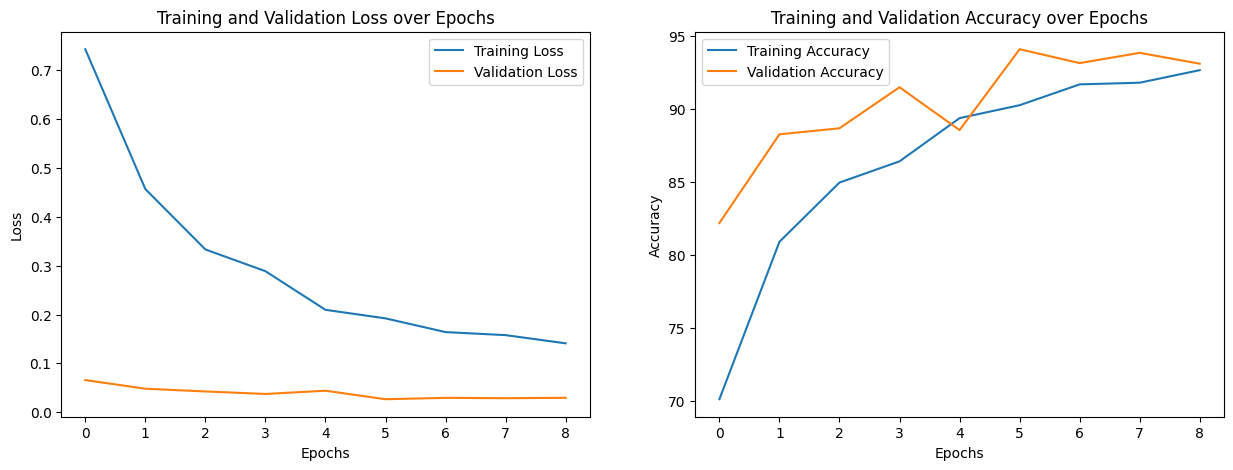

In [25]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [26]:
def predict_image(image_path):
  image = Image.open("/content/cat.jpg").convert('RGB')
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [ ]:
predict_image("/content/cat.jpg")

array(['wild'], dtype=object)

In [27]:
import torch
# Simpan model
torch.save(model.state_dict(), 'animal_model.pth')